In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import bisect
import lightgbm as lgb
from scipy.stats import spearmanr
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, '/Users/nishiharahiroto/Documents/programs/market-analytics-ver1')
from data.utils.database_manager import DatabaseManager

# ---- 定数 ----
ALL_TENORS   = ['3M', '6M', '9M', '1Y', '18M', '2Y', '3Y', '4Y', '5Y', '6Y', '7Y']
INNER_TENORS = ['6M', '9M', '1Y', '18M', '2Y', '3Y', '4Y', '5Y', '6Y']
MACRO_COLS   = ['USDJPY', 'DXY', 'nikkei', 'ust10y']
D, WINDOW    = 0.4, 50
OOS_START    = '2024-01-01'
OUTPUT_DIR   = '../outputs/'
RECENT_N     = 3          # 直近 N Fold での銘柄別 IC
os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')
print("Setup done.")


Setup done.


In [2]:
db = DatabaseManager()

# --- OIS ---
rows = db.get_ois_data(product_type='OIS')
df_swap_raw = pd.DataFrame(rows)
df_swap_raw['trade_date'] = pd.to_datetime(df_swap_raw['trade_date'])
df_ois_wide = df_swap_raw.pivot(index='trade_date', columns='tenor', values='rate')

available_tenors = [t for t in ALL_TENORS if t in df_ois_wide.columns]
df_ois = df_ois_wide[available_tenors].sort_index()

avail_set = set(available_tenors)
available_inner = [
    t for t in INNER_TENORS
    if t in avail_set
    and ALL_TENORS[ALL_TENORS.index(t) - 1] in avail_set
    and ALL_TENORS[ALL_TENORS.index(t) + 1] in avail_set
]
print(f"Available tenors : {available_tenors}")
print(f"Inner tenors (BF): {available_inner}")

# --- Macro ---
fx_q  = "SELECT trade_date, currency_pair, close_price FROM exchange_rates WHERE currency_pair IN ('USDJPY', 'DXY')"
df_fx = pd.DataFrame(db.select_as_dict(fx_q))
df_fx['trade_date'] = pd.to_datetime(df_fx['trade_date'])
df_fx = df_fx.pivot(index='trade_date', columns='currency_pair', values='close_price')

nk_q  = "SELECT trade_date, close_price as nikkei FROM stock_prices WHERE ticker = '^N225'"
df_nk = pd.DataFrame(db.select_as_dict(nk_q))
df_nk['trade_date'] = pd.to_datetime(df_nk['trade_date'])
df_nk = df_nk.set_index('trade_date')[['nikkei']]

us_q  = "SELECT trade_date, yield_value as ust10y FROM foreign_yields WHERE region = 'US' AND tenor = '10Y'"
df_us = pd.DataFrame(db.select_as_dict(us_q))
df_us['trade_date'] = pd.to_datetime(df_us['trade_date'])
df_us = df_us.set_index('trade_date')[['ust10y']]

boj_q = "SELECT meeting_date, policy_rate_after as policy_rate FROM boj_meetings ORDER BY meeting_date"
df_boj = pd.DataFrame(db.select_as_dict(boj_q))
df_boj['meeting_date'] = pd.to_datetime(df_boj['meeting_date'])
df_boj['policy_rate']  = df_boj['policy_rate'].astype(float)

print(f"OIS range: {df_ois.index.min().date()} ~ {df_ois.index.max().date()}, rows={len(df_ois)}")


INFO:data.utils.database_manager:DatabaseManager initialized for ep-calm-boat-a1zzrjkt-pooler.ap-southeast-1.aws.neon.tech


Available tenors : ['3M', '6M', '9M', '1Y', '18M', '2Y', '3Y', '4Y', '5Y', '6Y', '7Y']
Inner tenors (BF): ['6M', '9M', '1Y', '18M', '2Y', '3Y', '4Y', '5Y', '6Y']


OIS range: 2014-06-23 ~ 2026-03-27, rows=2874


In [3]:
df_all = df_ois.join([df_fx, df_nk, df_us], how='outer').sort_index()
df_all = df_all.dropna(how='all')
for col in df_all.columns:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

numeric_cols = [c for c in df_all.columns if not c.endswith('_is_imputed')]
for col in numeric_cols:
    df_all[f'{col}_is_imputed'] = df_all[col].isna().astype(int)

scaler  = StandardScaler()
df_sc   = pd.DataFrame(scaler.fit_transform(df_all[numeric_cols]),
                        columns=numeric_cols, index=df_all.index)
imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)
df_all[numeric_cols] = scaler.inverse_transform(imputer.fit_transform(df_sc))
print("MICE imputation done.")

df_boj_daily = df_boj.set_index('meeting_date')[['policy_rate']]
df_all['policy_rate'] = df_boj_daily.reindex(df_all.index, method='ffill')['policy_rate']

meeting_dates = df_boj['meeting_date'].sort_values().values
def days_to_next(date):
    future = meeting_dates[meeting_dates > date]
    return int((future[0] - date).days) if len(future) > 0 else np.nan
df_all['days_to_next_mpm'] = [days_to_next(d) for d in df_all.index]

df_all['is_meeting_day'] = df_all.index.isin(df_boj['meeting_date']).astype(int)
df_all['is_post_mpm']    = df_all['is_meeting_day'].rolling(window=6, min_periods=1).max().astype(int)
print("BOJ calendar done.")


MICE imputation done.
BOJ calendar done.


/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [4]:
def compute_butterfly(df_ois, all_tenors, inner_tenors):
    bf = pd.DataFrame(index=df_ois.index)
    for t in inner_tenors:
        idx    = all_tenors.index(t)
        prev_t = all_tenors[idx - 1]
        next_t = all_tenors[idx + 1]
        bf[t]  = 2 * df_ois[t] - df_ois[prev_t] - df_ois[next_t]
    return bf

def frac_diff(series, d=0.4, window=50):
    weights = [1.0]
    for k in range(1, window):
        weights.append(-weights[-1] * (d - k + 1) / k)
    weights = np.array(weights[::-1])
    arr = series.to_numpy(dtype=float)
    n, result = len(arr), np.full(len(arr), np.nan)
    if n < window:
        return pd.Series(result, index=series.index)
    from numpy.lib.stride_tricks import sliding_window_view
    wv   = sliding_window_view(arr, window_shape=window)
    dots = wv @ weights
    dots[np.isnan(wv).any(axis=1)] = np.nan
    result[window - 1:] = dots
    return pd.Series(result, index=series.index)

ois_imputed = df_all[[t for t in available_tenors]]
df_bf = compute_butterfly(ois_imputed, available_tenors, available_inner)

macro_fd = {f'{m}_fd': frac_diff(df_all[m], D, WINDOW)
            for m in MACRO_COLS if m in df_all.columns}
bf_fd    = {t: frac_diff(df_bf[t], D, WINDOW) for t in df_bf.columns}

df_all['front_spread'] = df_all['3M'] - df_all['policy_rate']
df_all['slope_3m7y']   = df_all['7Y'] - df_all['3M']

print("Butterfly + FD done. BF tenors:", df_bf.columns.tolist())


Butterfly + FD done. BF tenors: ['6M', '9M', '1Y', '18M', '2Y', '3Y', '4Y', '5Y', '6Y']


In [5]:
NON_FEATURE_COLS  = {'tenor_index', 'target', 'target_std', 'target_norm'}
TENOR_CODE_MAP    = {t: i for i, t in enumerate(INNER_TENORS)}

PARAMS = {
    'objective': 'regression', 'metric': 'rmse', 'verbosity': -1,
    'boosting_type': 'gbdt', 'random_state': 42, 'learning_rate': 0.05,
    'num_leaves': 31, 'feature_fraction': 0.8, 'bagging_fraction': 0.8,
    'bagging_freq': 5, 'min_data_in_leaf': 30, 'lambda_l2': 1.0,
}
NUM_BOOST_ROUND  = 100
TEST_WINDOW_DAYS = 90
PURGE_DAYS       = 5

def build_pooled_df_a(h):
    """Config A: bf_level 1本 + bf_fd 1本 + 共通コンテキスト"""
    flag_cols = [c for c in df_all.columns if c.endswith('_is_imputed')]
    all_rows  = []
    for tenor in available_inner:
        bf_s   = df_bf[tenor]
        target = bf_s.shift(-h) - bf_s
        row = {
            'tenor_code':       TENOR_CODE_MAP.get(tenor, 0),
            'bf_level':         bf_s,
            'bf_fd':            bf_fd[tenor],
            'front_spread':     df_all['front_spread'],
            'slope_3m7y':       df_all['slope_3m7y'],
            'policy_rate':      df_all['policy_rate'],
            'days_to_next_mpm': df_all['days_to_next_mpm'],
        }
        for col, s in macro_fd.items():
            row[col] = s
        for fc in flag_cols:
            row[fc] = df_all[fc]
        row['is_post_mpm'] = df_all['is_post_mpm']
        tmp = pd.DataFrame({'tenor_index': tenor, **row, 'target': target},
                           index=df_all.index)
        all_rows.append(tmp)

    df_long = pd.concat(all_rows).sort_index()
    feat_cols = [c for c in df_long.columns if c not in NON_FEATURE_COLS | {'is_post_mpm'}]
    df_long   = df_long.dropna(subset=feat_cols + ['target'])
    df_long   = df_long[df_long['is_post_mpm'] == 0].drop(columns='is_post_mpm')
    df_long['target_std']  = df_long.groupby('tenor_index')['target'].transform('std')
    df_long['target_norm'] = df_long['target'] / df_long['target_std']
    return df_long


def walk_forward(df_long, oos_start):
    target_col   = 'target_norm'
    feature_cols = [c for c in df_long.columns if c not in NON_FEATURE_COLS]
    unique_dates = sorted(df_long.index.unique())
    start_idx    = bisect.bisect_left(unique_dates, pd.to_datetime(oos_start))

    results, fold, current_idx = [], 0, start_idx
    while current_idx < len(unique_dates):
        train_end  = unique_dates[current_idx - 1]
        purge_end  = train_end - pd.Timedelta(days=PURGE_DAYS)
        test_start = unique_dates[current_idx]
        test_end   = test_start + pd.Timedelta(days=TEST_WINDOW_DAYS)

        train_mask = df_long.index <= purge_end
        test_mask  = (df_long.index >= test_start) & (df_long.index < test_end)

        if train_mask.sum() < 100 or test_mask.sum() < 10:
            current_idx = bisect.bisect_left(unique_dates, test_end)
            continue

        X_tr, y_tr = df_long.loc[train_mask, feature_cols], df_long.loc[train_mask, target_col]
        X_te       = df_long.loc[test_mask,  feature_cols]

        dtrain   = lgb.Dataset(X_tr, label=y_tr)
        model    = lgb.train(PARAMS, dtrain, num_boost_round=NUM_BOOST_ROUND)
        preds    = model.predict(X_te)
        train_ic = spearmanr(y_tr, model.predict(X_tr))[0]

        fold_df = df_long.loc[test_mask, ['tenor_index', 'target', 'target_std']].copy()
        fold_df['pred_norm'] = preds
        fold_df['pred']      = preds * fold_df['target_std']
        fold_df['actual']    = fold_df['target']
        fold_df['fold']      = fold
        fold_df['train_ic']  = train_ic
        fold_df['model']     = model   # 特徴量重要度用
        results.append(fold_df)

        fold += 1
        current_idx = bisect.bisect_left(unique_dates, test_end)

    return pd.concat(results).reset_index(names='date') if results else pd.DataFrame()

print("Functions defined. Running walk-forward (Config A)...")


Functions defined. Running walk-forward (Config A)...


In [6]:
walk = {}
feat_cols_ref = {}
models_by_fold = {}

for h in [3, 5]:
    print(f"--- h={h} ---")
    df_long = build_pooled_df_a(h)
    fc = [c for c in df_long.columns if c not in NON_FEATURE_COLS]
    feat_cols_ref[h] = fc

    res = walk_forward(df_long, OOS_START)

    # model オブジェクトをresから取り出して保存
    models_by_fold[h] = {}
    for fold_id, grp in res.groupby('fold'):
        models_by_fold[h][fold_id] = grp['model'].iloc[0]

    # model列を削除（DataFrameに保持不要）
    res = res.drop(columns=['model'])
    walk[h] = res

    ic_all = spearmanr(res['actual'], res['pred_norm'])[0]
    cs_ics = [spearmanr(g['actual'], g['pred_norm'])[0]
              for _, g in res.groupby('date') if len(g) >= 3]
    cs_ic  = np.nanmean(cs_ics)
    print(f"  Global IC={ic_all:.3f}, CS IC={cs_ic:.3f}, folds={res['fold'].nunique()}")

print("Done.")


--- h=3 ---


  Global IC=0.262, CS IC=0.175, folds=9
--- h=5 ---


  Global IC=0.239, CS IC=0.127, folds=9
Done.


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/249025047.py:38: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/249025047.py:38: UserWarning: Glyph 36817 (\N{CJK UNIFIED IDEOGRAPH-8FD1}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/249025047.py:38: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/249025047.py:38: UserWarning: Glyph 37329 (\N{CJK UNIFIED IDEOGRAPH-91D1}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/249025047.py:38: UserWarning: Glyph 26528 (\N{CJK UNIFIED IDEOGRAPH-67A0}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_2454

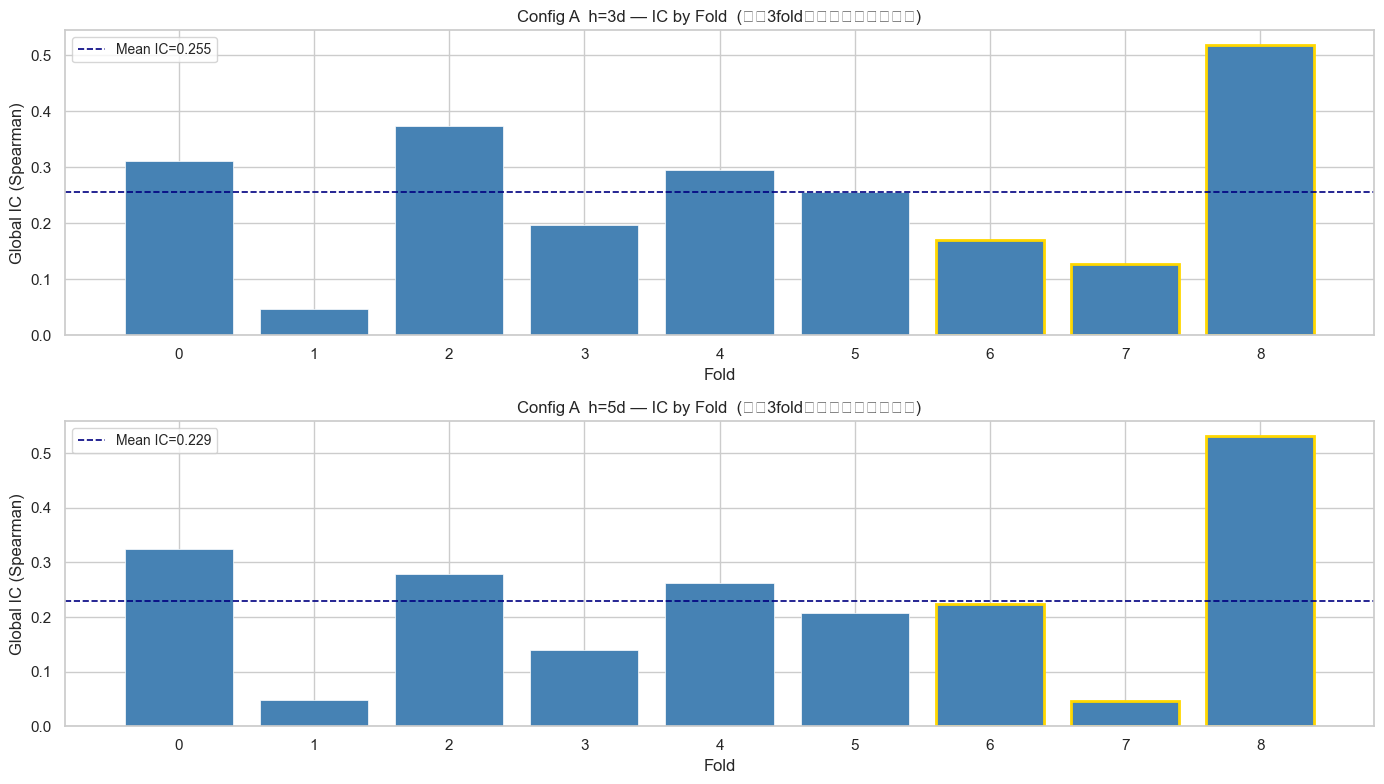

Saved: analysis_ic_by_fold.png


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, h in zip(axes, [3, 5]):
    res = walk[h]
    folds = sorted(res['fold'].unique())
    fold_ics = []
    for f in folds:
        g = res[res['fold'] == f]
        ic = spearmanr(g['actual'], g['pred_norm'])[0]
        fold_ics.append(ic)

    # 色付け: 正 = steelblue, 負 = tomato
    colors = ['steelblue' if v >= 0 else 'tomato' for v in fold_ics]
    bars = ax.bar(folds, fold_ics, color=colors, edgecolor='white', linewidth=0.5)

    # 直近 N Fold をハイライト
    recent_folds = folds[-RECENT_N:]
    for bar, f in zip(bars, folds):
        if f in recent_folds:
            bar.set_edgecolor('gold')
            bar.set_linewidth(2.0)

    # 平均 IC ライン
    mean_ic = np.nanmean(fold_ics)
    ax.axhline(mean_ic, color='navy', linewidth=1.2, linestyle='--',
               label=f'Mean IC={mean_ic:.3f}')
    ax.axhline(0, color='black', linewidth=0.7, linestyle='-')

    # テスト期間のラベル（折数多い場合は間引く）
    step = max(1, len(folds) // 8)
    ax.set_xticks(folds[::step])

    ax.set_title(f"Config A  h={h}d — IC by Fold  (直近{RECENT_N}foldを金枠でハイライト)", fontsize=12)
    ax.set_xlabel("Fold")
    ax.set_ylabel("Global IC (Spearman)")
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}analysis_ic_by_fold.png", dpi=150)
plt.show()
print("Saved: analysis_ic_by_fold.png")


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/3057517703.py:21: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/3057517703.py:21: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/3057517703.py:21: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/3057517703.py:22: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) Arial.
  plt.savefig(f"{OUTPUT_DIR}analysis_ic_by_tenor_all.png", dpi=150)
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/3057517703.py:22: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Arial.
  plt.savefig(f"{OUTPUT_

/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


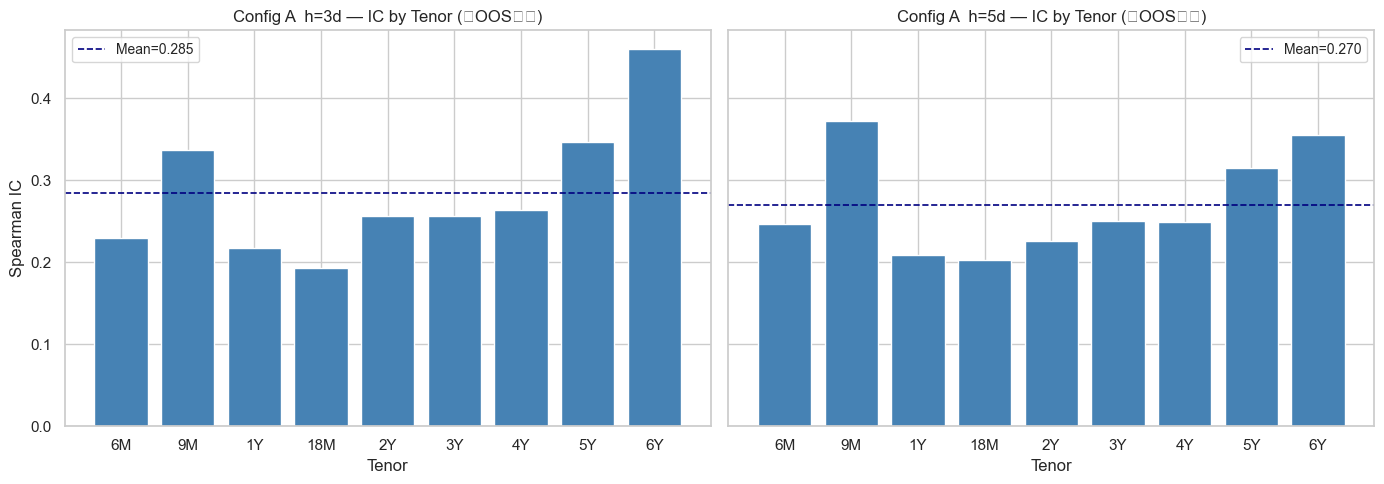

Saved: analysis_ic_by_tenor_all.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, h in zip(axes, [3, 5]):
    res = walk[h]
    tenor_ics = (
        res.groupby('tenor_index', observed=True)
           .apply(lambda x: spearmanr(x['actual'], x['pred_norm'])[0], include_groups=False)
           .reindex(available_inner)
    )
    colors = ['steelblue' if v >= 0 else 'tomato' for v in tenor_ics]
    ax.bar(tenor_ics.index, tenor_ics.values, color=colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.7)
    mean_val = np.nanmean(tenor_ics.values)
    ax.axhline(mean_val, color='navy', linewidth=1.2, linestyle='--',
               label=f'Mean={mean_val:.3f}')
    ax.set_title(f"Config A  h={h}d — IC by Tenor (全OOS期間)", fontsize=12)
    ax.set_xlabel("Tenor")
    ax.legend(fontsize=10)

axes[0].set_ylabel("Spearman IC")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}analysis_ic_by_tenor_all.png", dpi=150)
plt.show()
print("Saved: analysis_ic_by_tenor_all.png")


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/2401801673.py:28: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/2401801673.py:28: UserWarning: Glyph 36817 (\N{CJK UNIFIED IDEOGRAPH-8FD1}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/2401801673.py:29: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) Arial.
  plt.savefig(f"{OUTPUT_DIR}analysis_ic_by_tenor_recent.png", dpi=150)
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/2401801673.py:29: UserWarning: Glyph 36817 (\N{CJK UNIFIED IDEOGRAPH-8FD1}) missing from font(s) Arial.
  plt.savefig(f"{OUTPUT_DIR}analysis_ic_by_tenor_recent.png", dpi=150)


/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36817 (\N{CJK UNIFIED IDEOGRAPH-8FD1}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


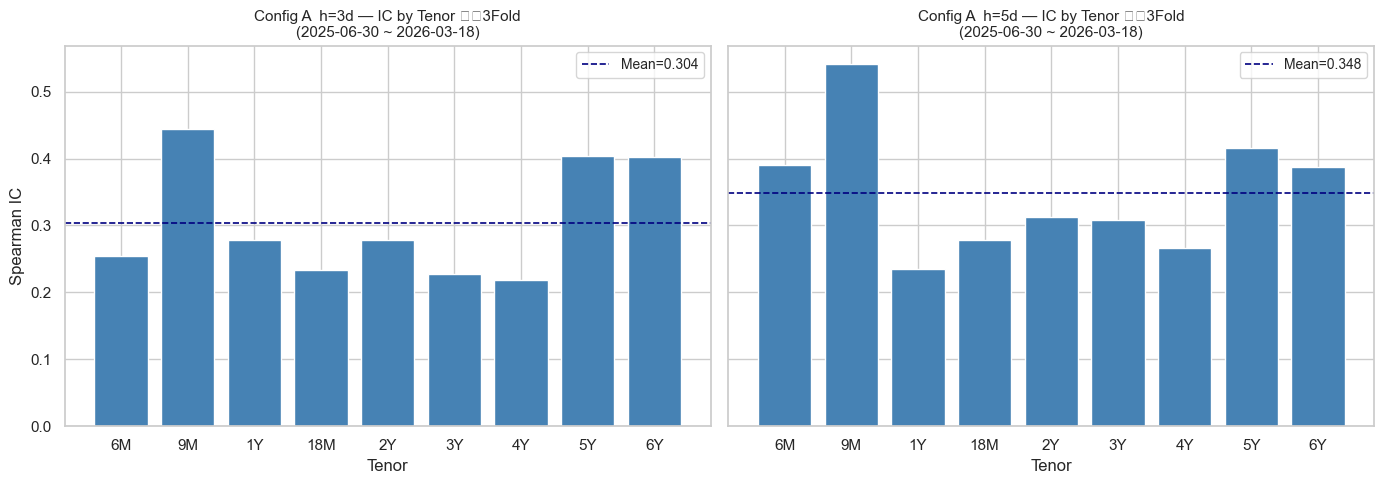

Saved: analysis_ic_by_tenor_recent.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, h in zip(axes, [3, 5]):
    res = walk[h]
    folds       = sorted(res['fold'].unique())
    recent_folds = folds[-RECENT_N:]
    res_recent   = res[res['fold'].isin(recent_folds)]

    start_date = res_recent['date'].min().date()
    end_date   = res_recent['date'].max().date()

    tenor_ics = (
        res_recent.groupby('tenor_index', observed=True)
                  .apply(lambda x: spearmanr(x['actual'], x['pred_norm'])[0], include_groups=False)
                  .reindex(available_inner)
    )
    colors = ['steelblue' if v >= 0 else 'tomato' for v in tenor_ics]
    ax.bar(tenor_ics.index, tenor_ics.values, color=colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.7)
    mean_val = np.nanmean(tenor_ics.values)
    ax.axhline(mean_val, color='navy', linewidth=1.2, linestyle='--',
               label=f'Mean={mean_val:.3f}')
    ax.set_title(f"Config A  h={h}d — IC by Tenor 直近{RECENT_N}Fold\n({start_date} ~ {end_date})", fontsize=11)
    ax.set_xlabel("Tenor")
    ax.legend(fontsize=10)

axes[0].set_ylabel("Spearman IC")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}analysis_ic_by_tenor_recent.png", dpi=150)
plt.show()
print("Saved: analysis_ic_by_tenor_recent.png")


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/11901535.py:29: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/11901535.py:29: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/11901535.py:29: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/11901535.py:29: UserWarning: Glyph 25512 (\N{CJK UNIFIED IDEOGRAPH-63A8}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/11901535.py:29: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79FB}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_2

/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25512 (\N{CJK UNIFIED IDEOGRAPH-63A8}) missing from font(s) Arial.
  fig.canv

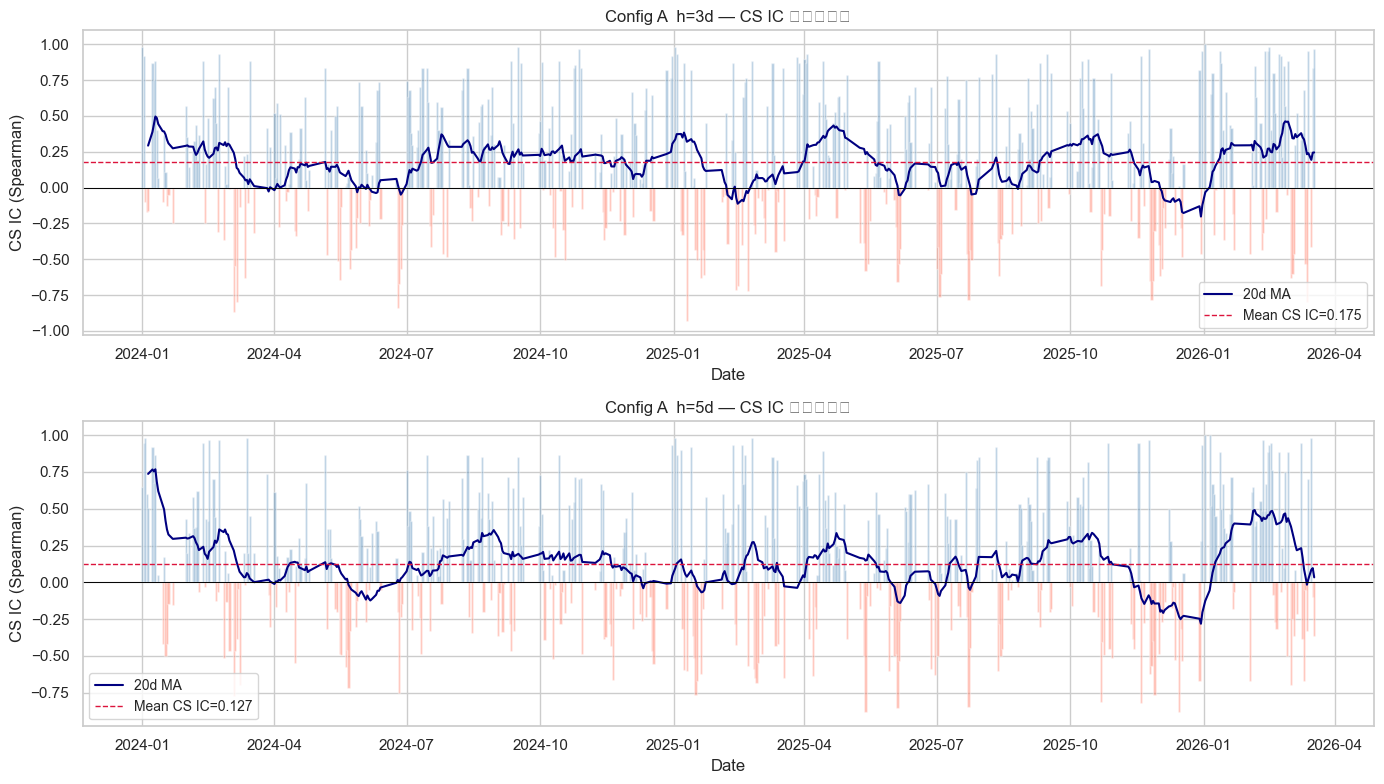

Saved: analysis_cs_ic_timeseries.png


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, h in zip(axes, [3, 5]):
    res = walk[h]
    # 日付ごとの CS IC（当日複数テナーをランク）
    daily_cs = (
        res.groupby('date')
           .apply(lambda g: spearmanr(g['actual'], g['pred_norm'])[0]
                  if len(g) >= 3 else np.nan, include_groups=False)
           .dropna()
    )
    # 20日移動平均
    rolling_ma = daily_cs.rolling(20, min_periods=5).mean()

    ax.bar(daily_cs.index, daily_cs.values,
           color=['steelblue' if v >= 0 else 'tomato' for v in daily_cs.values],
           alpha=0.4, width=1.5)
    ax.plot(rolling_ma.index, rolling_ma.values, color='navy',
            linewidth=1.5, label='20d MA')
    ax.axhline(0, color='black', linewidth=0.7)
    mean_cs = daily_cs.mean()
    ax.axhline(mean_cs, color='crimson', linewidth=1.0, linestyle='--',
               label=f'Mean CS IC={mean_cs:.3f}')
    ax.set_title(f"Config A  h={h}d — CS IC 時系列推移", fontsize=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("CS IC (Spearman)")
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}analysis_cs_ic_timeseries.png", dpi=150)
plt.show()
print("Saved: analysis_cs_ic_timeseries.png")


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/1649131258.py:38: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/1649131258.py:38: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/1649131258.py:38: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/1649131258.py:38: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/1649131258.py:38: UserWarning: Glyph 32066 (\N{CJK UNIFIED IDEOGRAPH-7D42}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/i

/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) Arial.
  fig.canv

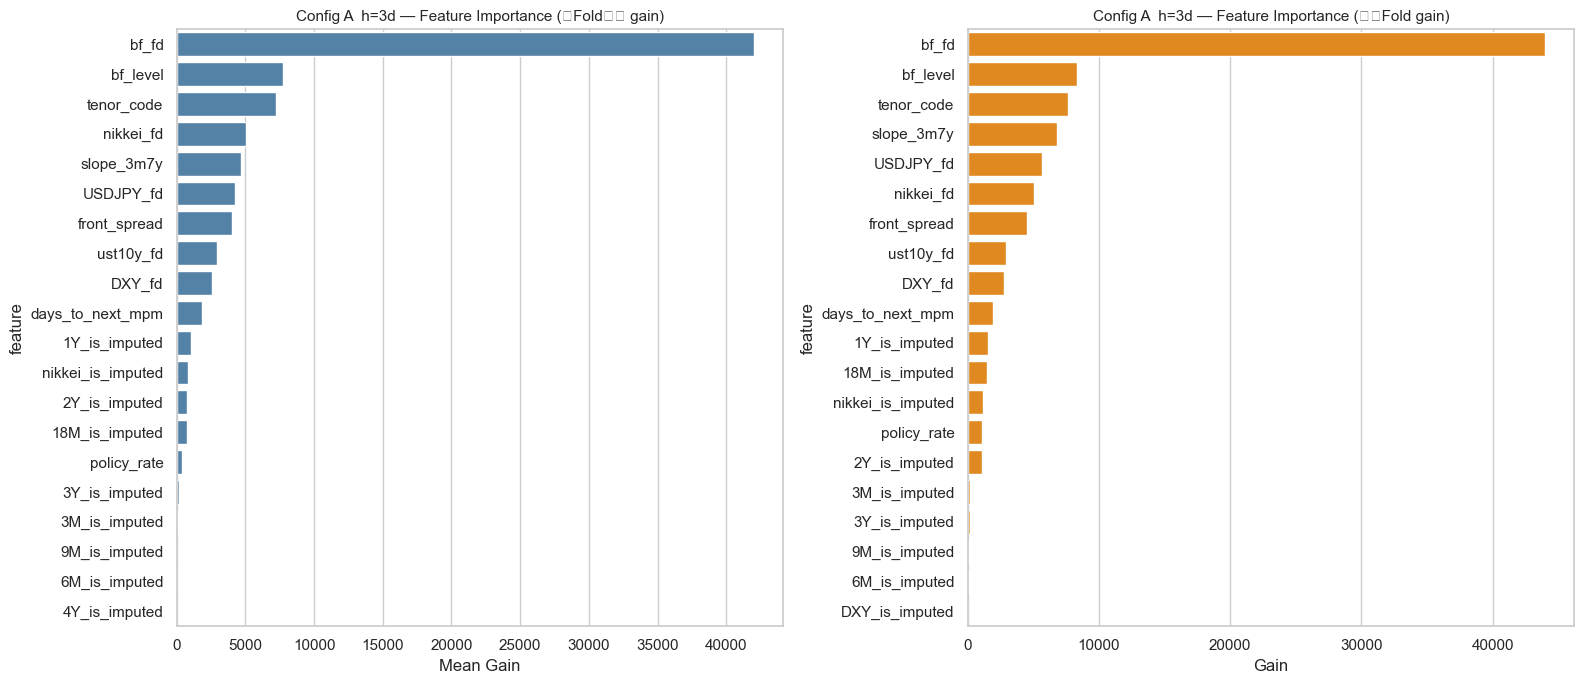

/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/1649131258.py:38: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) Arial.
  plt.tight_layout()


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/1649131258.py:38: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/1649131258.py:38: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/1649131258.py:38: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/1649131258.py:38: UserWarning: Glyph 32066 (\N{CJK UNIFIED IDEOGRAPH-7D42}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/1649131258.py:39: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) Arial.
  plt.savefig(f"{OUTPUT_DIR}analysis_feature_importance_{h}d.png", dpi=

h=3: Top5 features = ['bf_fd', 'bf_level', 'tenor_code', 'nikkei_fd', 'slope_3m7y']


/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) Arial.
  fig.canv

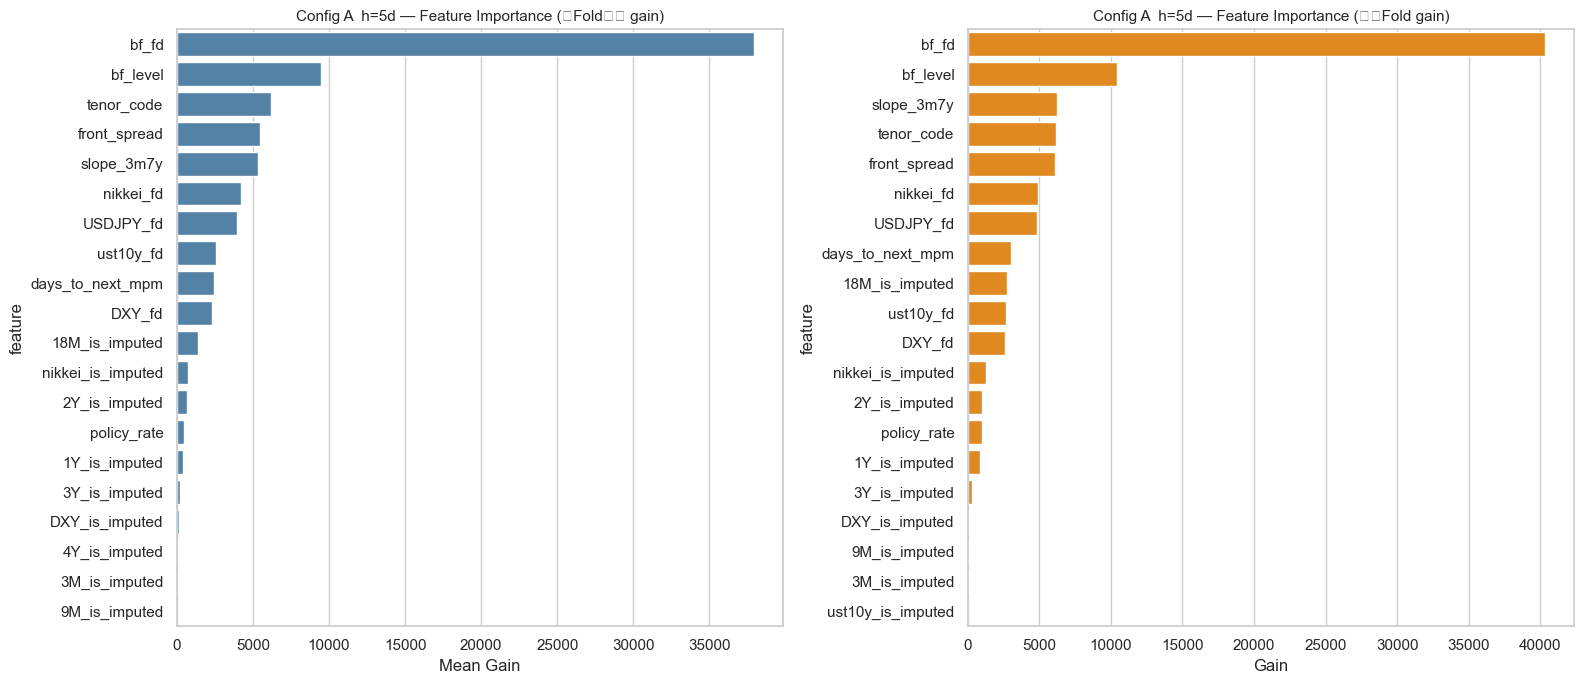

h=5: Top5 features = ['bf_fd', 'bf_level', 'tenor_code', 'front_spread', 'slope_3m7y']


In [11]:
for h in [3, 5]:
    fc = feat_cols_ref[h]
    n_feats = len(fc)

    # --- 全Fold平均の Feature Importance ---
    imp_matrix = np.zeros((len(models_by_fold[h]), n_feats))
    for i, (fold_id, model) in enumerate(sorted(models_by_fold[h].items())):
        gains = model.feature_importance(importance_type='gain')
        # feature_name() の順序と fc の順序を合わせる
        fname = model.feature_name()
        imp_dict = dict(zip(fname, gains))
        imp_matrix[i] = [imp_dict.get(f, 0.0) for f in fc]

    mean_gains = imp_matrix.mean(axis=0)
    imp_df = pd.DataFrame({'feature': fc, 'mean_gain': mean_gains})
    imp_df = imp_df.sort_values('mean_gain', ascending=False).head(20)

    # --- 最終Foldの Feature Importance ---
    last_fold = max(models_by_fold[h].keys())
    last_model = models_by_fold[h][last_fold]
    fname = last_model.feature_name()
    gains = last_model.feature_importance(importance_type='gain')
    last_imp = pd.DataFrame({'feature': fname, 'last_gain': gains})
    last_imp = last_imp.sort_values('last_gain', ascending=False).head(20)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # 全Fold平均
    sns.barplot(data=imp_df, x='mean_gain', y='feature', color='steelblue', ax=ax1)
    ax1.set_title(f"Config A  h={h}d — Feature Importance (全Fold平均 gain)", fontsize=11)
    ax1.set_xlabel("Mean Gain")

    # 最終Fold
    sns.barplot(data=last_imp, x='last_gain', y='feature', color='darkorange', ax=ax2)
    ax2.set_title(f"Config A  h={h}d — Feature Importance (最終Fold gain)", fontsize=11)
    ax2.set_xlabel("Gain")

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}analysis_feature_importance_{h}d.png", dpi=150)
    plt.show()
    print(f"h={h}: Top5 features = {imp_df['feature'].head(5).tolist()}")


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/4225496918.py:26: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/4225496918.py:26: UserWarning: Glyph 36817 (\N{CJK UNIFIED IDEOGRAPH-8FD1}) missing from font(s) Arial.
  plt.tight_layout()


/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/4225496918.py:27: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) Arial.
  plt.savefig(f"{OUTPUT_DIR}analysis_scatter_recent.png", dpi=150)
/var/folders/g9/c40h_n0d727bl31nhmg4y2fh0000gn/T/ipykernel_24543/4225496918.py:27: UserWarning: Glyph 36817 (\N{CJK UNIFIED IDEOGRAPH-8FD1}) missing from font(s) Arial.
  plt.savefig(f"{OUTPUT_DIR}analysis_scatter_recent.png", dpi=150)


/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36817 (\N{CJK UNIFIED IDEOGRAPH-8FD1}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


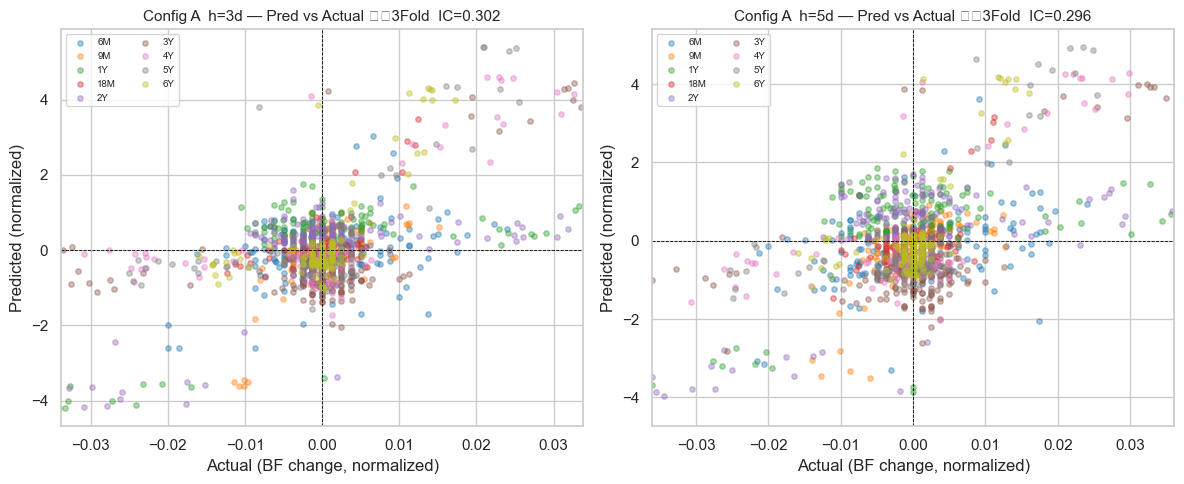

Saved: analysis_scatter_recent.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, h in zip(axes, [3, 5]):
    res = walk[h]
    folds        = sorted(res['fold'].unique())
    recent_folds = folds[-RECENT_N:]
    res_r        = res[res['fold'].isin(recent_folds)]

    tenors = res_r['tenor_index'].unique()
    palette = sns.color_palette("tab10", len(tenors))
    for tenor, color in zip(available_inner, palette):
        g = res_r[res_r['tenor_index'] == tenor]
        ax.scatter(g['actual'], g['pred_norm'], label=tenor,
                   color=color, alpha=0.4, s=15)

    xlim = max(abs(res_r['actual'].quantile(0.01)), abs(res_r['actual'].quantile(0.99)))
    ax.set_xlim(-xlim, xlim)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.6, linestyle='--')
    ic = spearmanr(res_r['actual'], res_r['pred_norm'])[0]
    ax.set_title(f"Config A  h={h}d — Pred vs Actual 直近{RECENT_N}Fold  IC={ic:.3f}", fontsize=11)
    ax.set_xlabel("Actual (BF change, normalized)")
    ax.set_ylabel("Predicted (normalized)")
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}analysis_scatter_recent.png", dpi=150)
plt.show()
print("Saved: analysis_scatter_recent.png")


## 分析結果サマリー

**モデル**: Config A (spot_rate_bf_base)
- 目的変数: バタフライ変化量 BF_{t+h} − BF_t（テナー別 std 正規化）
- 特徴量: bf_level(1本), bf_fd(1本), front_spread, slope_3m7y, policy_rate, days_to_next_mpm, マクロFD

### 可視化チェックリスト

| 図 | ファイル名 | 確認ポイント |
|----|-----------|-------------|
| IC by Fold | analysis_ic_by_fold.png | Fold間の安定性。直近Fold(金枠)の傾向 |
| IC by Tenor (全OOS) | analysis_ic_by_tenor_all.png | どのテナーで予測精度が高いか |
| IC by Tenor (直近3Fold) | analysis_ic_by_tenor_recent.png | 直近の銘柄別精度 |
| CS IC 時系列 | analysis_cs_ic_timeseries.png | レジーム変化・相場環境による変動 |
| Feature Importance | analysis_feature_importance_{h}d.png | どの特徴量が寄与しているか |
| Scatter 直近 | analysis_scatter_recent.png | 予測と実績のばらつきと方向性 |
